# Framework Demo — Streaming Signal Decomposition

This notebook demonstrates the core streaming SSD pipeline on synthetic signals.

## 1. Imports and Setup

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Ensure project root is on path (works when run from notebooks/ or project root)
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.synthetic.generators import two_sinusoids
from src.metrics.stability import nmse, qrf
from src.ssd.core import SSD
from src.streaming.component_matcher import ComponentMatcher
from src.streaming.trajectory_store import TrajectoryStore
from src.streaming.window_manager import WindowManager

# Demo parameters: smaller signal for fast execution (~30–60 s)
FS = 200.0
N = 1200
WINDOW_LEN = 400
STRIDE = 200
SEED = 42

## 2. Generate Synthetic Signal

In [4]:
signal = two_sinusoids(
    N=N,
    f1=5.0,
    f2=25.0,
    fs=FS,
    snr_db=25.0,
    seed=SEED,
)
t = np.arange(N) / FS
print(f"Signal length: {N} samples ({N/FS:.2f} s at {FS} Hz)")

Signal length: 1200 samples (6.00 s at 200.0 Hz)


## 3. Batch SSD Decomposition

In [5]:
ssd = SSD(fs=FS, nmse_threshold=0.01, max_iter=15)
components_batch = ssd.fit(signal)
residual_batch = components_batch[-1]
components_only = components_batch[:-1]

recon_batch = sum(components_only) + residual_batch
qrf_batch = qrf(signal, recon_batch)
nmse_batch = nmse(residual_batch, signal)

print(f"Extracted {len(components_only)} components + residual")
print(f"QRF: {qrf_batch:.1f} dB")
print(f"NMSE: {nmse_batch:.4f}")

Extracted 2 components + residual
QRF: 323.1 dB
NMSE: 0.0022


## 4. Streaming Pipeline

In [6]:
wm = WindowManager(window_len=WINDOW_LEN, stride=STRIDE, fs=FS)
ssd_stream = SSD(fs=FS, nmse_threshold=0.01, max_iter=15)
matcher = ComponentMatcher(distance="d_corr", fs=FS)
store = TrajectoryStore(max_components=8, max_len=N)

prev_components = []
overlap = wm.overlap
all_windows: list[np.ndarray] = []
all_components: list[list[np.ndarray]] = []
qrfs: list[float] = []

for sample_idx in range(N):
    window = wm.push(float(signal[sample_idx]))
    if window is None:
        continue

    comps = ssd_stream.fit(window)
    residual = comps[-1]
    comps_no_res = comps[:-1]

    matching = (
        {i: None for i in range(len(comps_no_res))}
        if len(prev_components) == 0
        else matcher.match(prev_components, comps_no_res, overlap)
    )

    window_start = sample_idx - WINDOW_LEN + 1
    store.update(window_start, comps_no_res, matching, overlap)

    recon = sum(comps_no_res) + residual
    qrfs.append(qrf(window, recon))
    all_windows.append(window)
    all_components.append(comps_no_res)
    prev_components = comps_no_res

print(f"Processed {len(all_windows)} windows")
print(f"Mean QRF per window: {np.mean(qrfs):.1f} dB")

Processed 5 windows
Mean QRF per window: 322.8 dB


## 5. Metrics and Evaluation

In [7]:
from src.metrics.stability import energy_continuity, frequency_drift

# Per-window metrics: dominant frequency and total energy
freqs_per_window = []
energies_per_window = []
for comps in all_components:
    if comps:
        c = comps[0]
        f = np.fft.rfftfreq(len(c), d=1.0 / FS)
        mag = np.abs(np.fft.rfft(c))
        freqs_per_window.append(float(f[np.argmax(mag)]))
    energies_per_window.append(sum(np.dot(c, c) for c in comps))

fd = frequency_drift(freqs_per_window)
ec = energy_continuity(energies_per_window)

print(f"Frequency drift (variance): {fd:.4f}")
print(f"Energy continuity (sum sq diffs): {ec:.4e}")

Frequency drift (variance): 0.0000
Energy continuity (sum sq diffs): 3.2649e+01


## 6. Visualisation

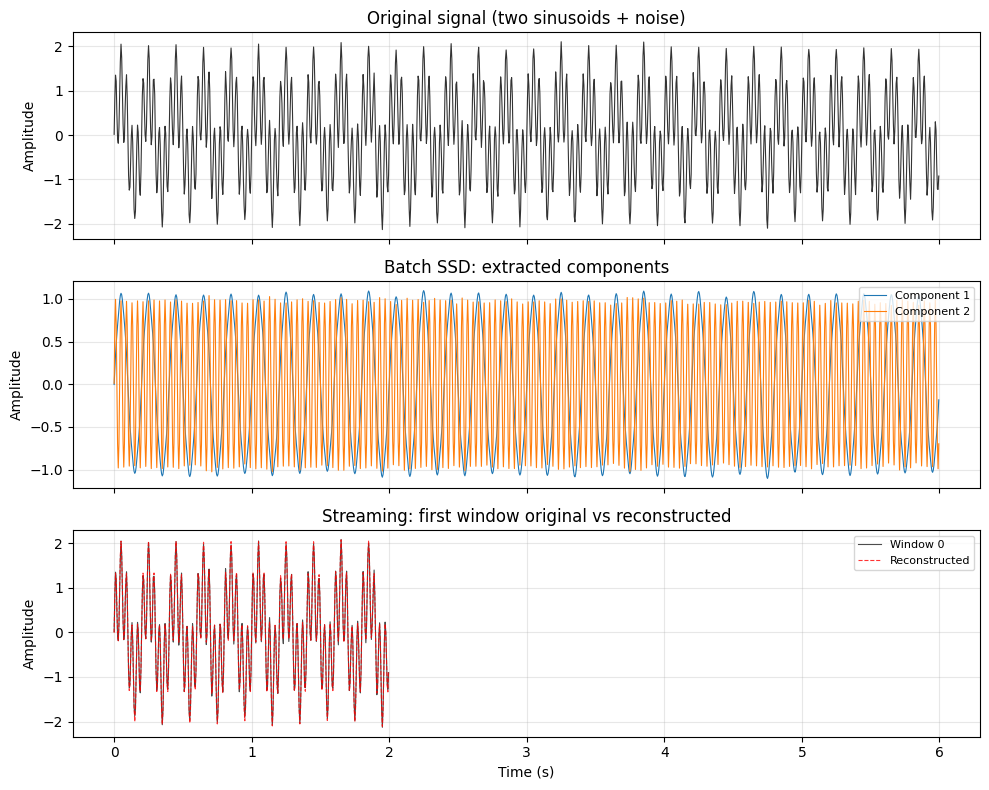

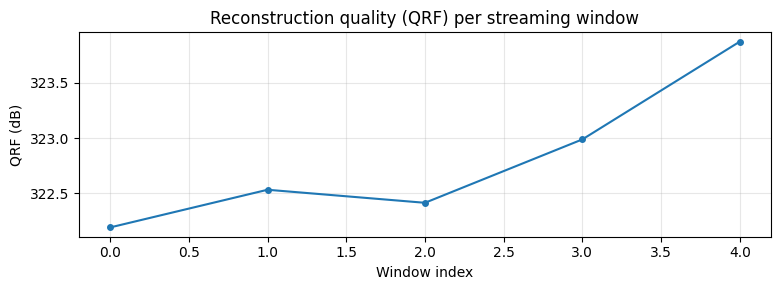

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Original signal
axes[0].plot(t, signal, "k-", linewidth=0.8, alpha=0.8)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Original signal (two sinusoids + noise)")
axes[0].grid(True, alpha=0.3)

# Batch SSD components (first 3)
for i, comp in enumerate(components_only[:3]):
    axes[1].plot(t, comp, linewidth=0.8, label=f"Component {i+1}")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Batch SSD: extracted components")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True, alpha=0.3)

# Streaming: first window original vs reconstructed (components only; residual small)
t_win = np.arange(WINDOW_LEN) / FS
win_0 = all_windows[0]
recon_0 = sum(all_components[0])
axes[2].plot(t_win, win_0, "k-", linewidth=0.8, alpha=0.7, label="Window 0")
axes[2].plot(t_win, recon_0, "r--", linewidth=0.8, alpha=0.8, label="Reconstructed")
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Streaming: first window original vs reconstructed")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# QRF per window
fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.plot(np.arange(len(qrfs)), qrfs, "o-", markersize=4)
ax2.set_xlabel("Window index")
ax2.set_ylabel("QRF (dB)")
ax2.set_title("Reconstruction quality (QRF) per streaming window")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()